In [1]:
import pandas as pd


In [2]:
#!pip install xlrd

In [3]:
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Load data

my_schema = "team_3"

mart_all_data = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)



mart_all_data.head(2)

,transaction_date,transaction_id,customer_id,customer_gender,customer_location,customer_tenure_months,produkt_sku,product_category,quantity,avg_price,delivery_charges,revenue,coupon_status,discount_pct,gst_onsale,daily_offline,daily_online,transaction_month,transaction_month_str
0,2019-04-19,25990,15811,F,Illinois,27,GGOEWCKQ085457,Accessories,1,16.99,6.0,22.99,Clicked,10.0,0.1,4000,1754.92,4.0,apr
1,2019-04-07,25038,17999,F,New Jersey,30,GGOEGBPB081999,Accessories,1,49.99,6.5,56.49,Used,10.0,0.1,2500,2719.46,4.0,apr


In [4]:
mart_all_data.columns

Index(['transaction_date', 'transaction_id', 'customer_id', 'customer_gender',
       'customer_location', 'customer_tenure_months', 'produkt_sku',
       'product_category', 'quantity', 'avg_price', 'delivery_charges',
       'revenue', 'coupon_status', 'discount_pct', 'gst_onsale',
       'daily_offline', 'daily_online', 'transaction_month',
       'transaction_month_str'],
      dtype='object')

In [5]:
# 1. Gross Sales
mart_all_data['gross_sales'] = mart_all_data['quantity'] * mart_all_data['avg_price']

# 2. Discount Amount
mart_all_data['discount_amount'] = mart_all_data['gross_sales'] * (mart_all_data['discount_pct'] / 100)

# 3. Net Subtotal
mart_all_data['net_subtotal'] = mart_all_data['gross_sales'] - mart_all_data['discount_amount']

# 4. Pre-Tax Total (add delivery)
mart_all_data['pre_tax_total'] = mart_all_data['net_subtotal'] + mart_all_data['delivery_charges']

# 5. GST Amount
mart_all_data['gst_amount'] = mart_all_data['pre_tax_total'] * (mart_all_data['gst_onsale'] / 100)

# 6. Final Invoice (what customer paid)
mart_all_data['invoice_value'] = mart_all_data['pre_tax_total'] + mart_all_data['gst_amount']

# 7. Net Revenue (excludes GST remitted to govt)
mart_all_data['net_revenue'] = mart_all_data['pre_tax_total']

In [6]:
historical_ltv = mart_all_data.groupby('customer_id')['net_revenue'].sum().reset_index()
historical_ltv.columns = ['customer_id', 'historical_ltv']
print(historical_ltv.head())

   customer_id  historical_ltv
0        12346         171.693
1        12347       10589.289
2        12348        1339.652
3        12350        1079.929
4        12356        1647.219


In [7]:
mart_all_data.columns

Index(['transaction_date', 'transaction_id', 'customer_id', 'customer_gender',
       'customer_location', 'customer_tenure_months', 'produkt_sku',
       'product_category', 'quantity', 'avg_price', 'delivery_charges',
       'revenue', 'coupon_status', 'discount_pct', 'gst_onsale',
       'daily_offline', 'daily_online', 'transaction_month',
       'transaction_month_str', 'gross_sales', 'discount_amount',
       'net_subtotal', 'pre_tax_total', 'gst_amount', 'invoice_value',
       'net_revenue'],
      dtype='object')

# We are using the classical “probabilistic LTV modeling” approach with the lifetimes Python package, which implements the BG/NBD (Beta-Geometric/Negative Binomial Distribution) and Gamma-Gamma models.

How Does This Approach Work?
- BG/NBD model: Predicts the probability a customer will make future purchases and the expected number of transactions (frequency).

- Gamma-Gamma model: Predicts the average monetary value per transaction (monetary value).

- Combined:
Predicted LTV = Predicted purchases in 6 months × Predicted average value per purchase



In [8]:
#!pip install lifetimes

In [9]:
from lifetimes.utils import summary_data_from_transaction_data

# Ensure transaction_date is datetime
mart_all_data['transaction_date'] = pd.to_datetime(mart_all_data['transaction_date'])

# Generate summary for LTV modeling, converts the transaction-level data to a customer-level summary.
summary = summary_data_from_transaction_data(
    mart_all_data,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='net_revenue',
    observation_period_end=mart_all_data['transaction_date'].max()
)

print(summary.head())


             frequency  recency      T  monetary_value
customer_id                                           
12346              0.0      0.0  107.0           0.000
12347              2.0    223.0  282.0        1163.375
12348              1.0    119.0  192.0         693.731
12350              0.0      0.0   17.0           0.000
12356              0.0      0.0  107.0           0.000


Fit BG/NBD model (BetaGeoFitter) to estimate repeat probability and expected number of purchases.

BG/NBD is a probabilistic model for repeat-purchase transactions:

Estimates for each customer:

Probability they are still “alive” (will buy again)

Expected number of transactions in a future period

In [10]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter()
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

<lifetimes.BetaGeoFitter: fitted with 1468 subjects, a: 0.58, alpha: 61.18, b: 1.49, r: 0.54>

Fit Gamma-Gamma model to estimate average revenue per purchase for repeaters.

Gamma-Gamma model predicts average transaction value for each customer, based on their history.

Only works for customers with at least 2 purchases (frequency > 0).

In [11]:
from lifetimes import GammaGammaFitter

# Only use customers with freq > 0
returning_customers = summary[summary['frequency'] > 0]

ggf = GammaGammaFitter()
ggf.fit(returning_customers['frequency'], returning_customers['monetary_value'])

<lifetimes.GammaGammaFitter: fitted with 734 subjects, p: 0.60, q: 4.81, v: 7983.58>

For each customer, predict:

How many times they will purchase in the next 180 days (using BG/NBD)

Their expected average purchase value (using Gamma-Gamma)

Customers with frequency = 0 will have predicted avg value = NaN, but their predicted purchases will be > 0 if they are likely to return.

In [ ]:
# Predict expected number of purchases
summary['predicted_purchases_6m'] = bgf.conditional_expected_number_of_purchases_up_to_time(180,
            summary['frequency'], summary['recency'], summary['T'])

# Predict expected average revenue
summary['predicted_avg_value'] = ggf.conditional_expected_average_profit(summary['frequency'], summary['monetary_value'])

# Final LTV
summary['predicted_ltv_6m'] = summary['predicted_purchases_6m'] * summary['predicted_avg_value']

# View top customers by predicted LTV
summary[['predicted_ltv_6m']].sort_values(by='predicted_ltv_6m', ascending=False).head()

,predicted_LTV_6m
customer_id,
15311,21033.926265
14606,17049.487254
14911,15974.121923
17841,14981.066823
13089,9469.652429


LTV:
Predicted # of purchases × Predicted avg purchase value (in the next 6 months)

In [13]:
summary.head(2)

,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_LTV_6m
customer_id,,,,,,,
12346,0.0,0.0,107.0,0.000,0.486163,1265.594052,615.284554
12347,2.0,223.0,282.0,1163.375,0.867946,1240.987166,1077.109890


In [14]:
# Merge with demographics or customer segments
mart_customers= pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_customers",
    engine,
)
ltv_final = summary.reset_index().merge(mart_customers, on='customer_id', how='left')

# Export to CSV for Tableau
#ltv_final.to_csv("Customer_LTV_Summary.csv", index=False)

In [15]:
ltv_final.head(2)

,customer_id,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_LTV_6m,gender,location,tenure_months
0,12346,0.0,0.0,107.0,0.000,0.486163,1265.594052,615.284554,F,New York,31
1,12347,2.0,223.0,282.0,1163.375,0.867946,1240.987166,1077.109890,M,New York,20


In [16]:
ltv_final.describe()

,customer_id,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_LTV_6m,tenure_months
count,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000
mean,15314.386240,1.185286,64.358992,208.651226,639.936538,0.690629,1263.838591,877.776033,25.912125
std,1744.000367,2.235245,97.383296,104.677684,1331.197205,0.760671,227.004700,1174.402608,13.959667
min,12346.000000,0.000000,0.000000,0.000000,0.000000,0.000015,564.927071,0.035771,2.000000
25%,13830.500000,0.000000,0.000000,128.000000,0.000000,0.293539,1172.455841,363.268275,14.000000
50%,15300.000000,0.500000,0.500000,222.000000,3.836500,0.448239,1265.594052,553.572812,26.000000
75%,16882.250000,2.000000,121.000000,294.250000,812.452250,0.831766,1265.594052,1055.716632,38.000000
max,18283.000000,33.000000,358.000000,364.000000,19334.968000,10.239648,3738.084777,21033.926265,50.000000


In [ ]:
# Make sure your cutoff date is set
cutoff_date = pd.Timestamp('2019-04-01')

# Actual LTV: sum of net revenue per customer in the 6 months after cutoff
future_6m_end = cutoff_date + pd.DateOffset(days=180)
actual_ltv = (
    mart_all_data[
        (mart_all_data['transaction_date'] >= cutoff_date) &
        (mart_all_data['transaction_date'] < future_6m_end)
    ]
    .groupby('customer_id')['net_revenue'].sum()
    .reset_index()
    .rename(columns={'net_revenue': 'actual_ltv_6m'})
)

# Merge actual LTV with the summary containing predicted LTV
ltv_eval = summary.reset_index().merge(actual_ltv, on='customer_id', how='left')
ltv_eval['actual_ltv_6m'] = ltv_eval['actual_ltv_6m'].fillna(0)  # For those with no purchases


Model Evaluation: Comparing Errors to Actual LTV Values

Mean actual 6-month LTV: $1,339.71
Median actual 6-month LTV: $396.13
RMSE (model error): $2,419.39
MAE (model error): $1,213.11



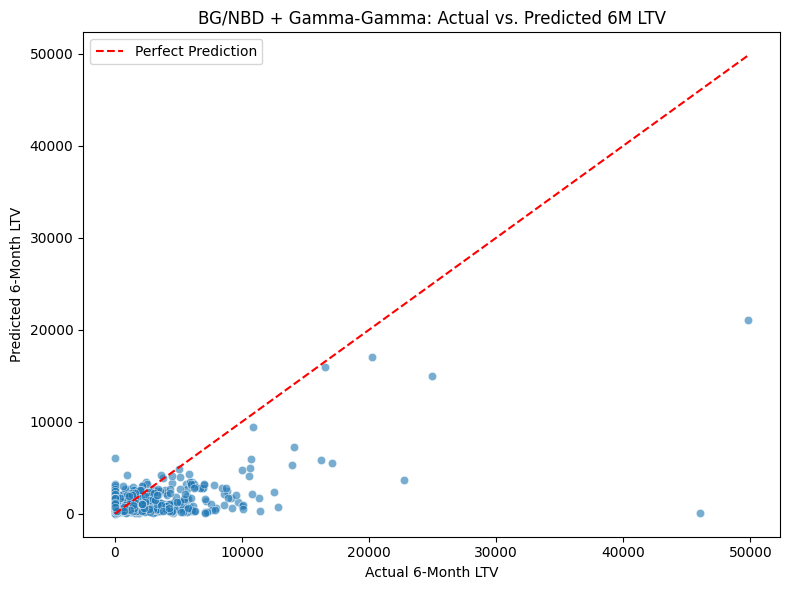

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(ltv_eval['actual_ltv_6m'], ltv_eval['predicted_ltv_6m']))
mae = mean_absolute_error(ltv_eval['actual_ltv_6m'], ltv_eval['predicted_ltv_6m'])
mean_actual_ltv = ltv_eval['actual_ltv_6m'].mean()
median_actual_ltv = ltv_eval['actual_ltv_6m'].median()

print("Model Evaluation: Comparing Errors to Actual LTV Values\n")
print(f"Mean actual 6-month LTV: ${mean_actual_ltv:,.2f}")
print(f"Median actual 6-month LTV: ${median_actual_ltv:,.2f}")
print(f"RMSE (model error): ${rmse:,.2f}")
print(f"MAE (model error): ${mae:,.2f}\n")


# Plot actual vs. predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x='actual_ltv_6m', y='predicted_ltv_6m', data=ltv_eval, alpha=0.6)
plt.plot(
    [ltv_eval['actual_ltv_6m'].min(), ltv_eval['actual_ltv_6m'].max()],
    [ltv_eval['actual_ltv_6m'].min(), ltv_eval['actual_ltv_6m'].max()],
    color='red', linestyle='--', label='Perfect Prediction'
)
plt.xlabel("Actual 6-Month LTV")
plt.ylabel("Predicted 6-Month LTV")
plt.title("BG/NBD + Gamma-Gamma: Actual vs. Predicted 6M LTV")
plt.legend()
plt.tight_layout()
plt.show()


To compare the predicted LTV from the BG/NBD + Gamma-Gamma model with the actual LTV, we are going to do the following

Only include customers who are present in the summary table (i.e., have at least one purchase in the “training” period).

NB: To to match exactly how Gamma-Gamma is fit (i.e., only customers with frequency > 0), we can restrict evaluation to those customers.

In [19]:
# Customers present in summary (usually all with at least 1 purchase in the period)
#customer_ids = summary.reset_index()['customer_id']

In [20]:
#only customers with frequency > 0 (i.e., at least 2 purchases in history) 
customer_ids = summary[summary['frequency'] > 0].reset_index()['customer_id']

In [ ]:
# Let's use the same cutoff_date and 6-month window as for prediction
cutoff_date = pd.Timestamp('2019-04-01')
future_6m_end = cutoff_date + pd.DateOffset(days=180)

# Calculate actual LTV for those customers
actual_ltv = (
    mart_all_data[
        (mart_all_data['customer_id'].isin(customer_ids)) &
        (mart_all_data['transaction_date'] >= cutoff_date) &
        (mart_all_data['transaction_date'] < future_6m_end)
    ]
    .groupby('customer_id')['net_revenue'].sum()
    .reset_index()
    .rename(columns={'net_revenue': 'actual_ltv_6m'})
)

In [ ]:
# Merge predicted and actual evaluation
eval_df = summary.reset_index()[['customer_id', 'predicted_ltv_6m']].merge(
    actual_ltv, on='customer_id', how='left'
)
eval_df['actual_ltv_6m'] = eval_df['actual_ltv_6m'].fillna(0)

RMSE: 2316.01
MAE: 1107.97


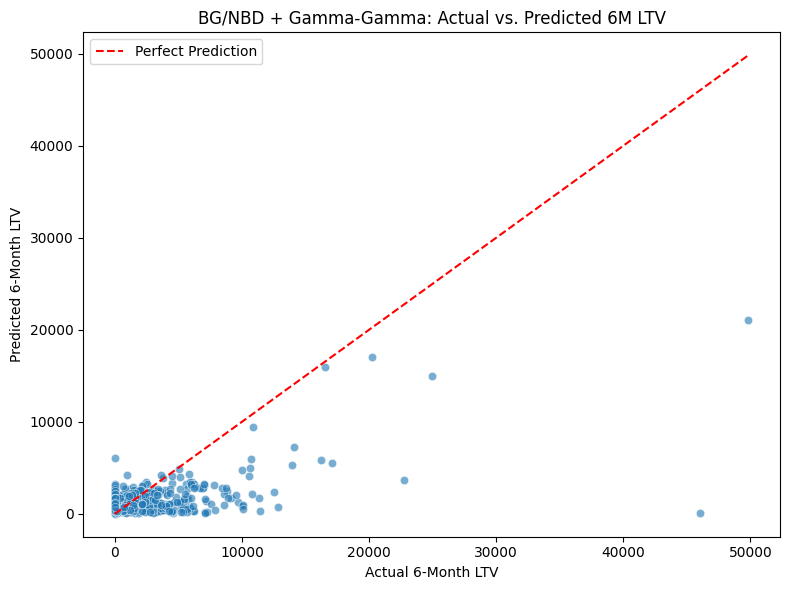

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rmse = np.sqrt(mean_squared_error(eval_df['actual_ltv_6m'], eval_df['predicted_ltv_6m']))
mae = mean_absolute_error(eval_df['actual_ltv_6m'], eval_df['predicted_ltv_6m'])

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(8,6))
sns.scatterplot(x='actual_ltv_6m', y='predicted_ltv_6m', data=eval_df, alpha=0.6)
plt.plot([eval_df['actual_ltv_6m'].min(), eval_df['actual_ltv_6m'].max()],
         [eval_df['actual_ltv_6m'].min(), eval_df['actual_ltv_6m'].max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual 6-Month LTV")
plt.ylabel("Predicted 6-Month LTV")
plt.title("BG/NBD + Gamma-Gamma: Actual vs. Predicted 6M LTV")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calculate actual mean and median LTV for the filtered customers
mean_actual_ltv = eval_df['actual_ltv_6m'].mean()
median_actual_ltv = eval_df['actual_ltv_6m'].median()

print(f"Mean actual 6M LTV (filtered customers): ${mean_actual_ltv:,.2f}")
print(f"Median actual 6M LTV (filtered customers): ${median_actual_ltv:,.2f}")

Mean actual 6M LTV (filtered customers): $1,056.13
Median actual 6M LTV (filtered customers): $0.00


Key Optimizations

- Outlier Removal: Caps extremely high revenues that distort Gamma-Gamma predictions.
- Penalizer Coefficient: Regularizes the fit, preventing overestimation for sparse buyers.
- Monetary Value Filtering: Removes unrealistic spending data points.
- LTV Capping: Applies a ceiling (e.g., 99th percentile) to avoid absurdly high predictions.
- Frequency > 0 Filter: Ensures predictions are based on repeat behavior.

In [ ]:
import pandas as pd
import numpy as np
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Preprocess data to avoid outliers dominating results
# Remove customers with extremely high monetary value (top 1%)
q99 = mart_all_data['net_revenue'].quantile(0.99)
clean_data = mart_all_data[mart_all_data['net_revenue'] <= q99].copy()

# Generate summary for LTV modeling
summary = summary_data_from_transaction_data(
    clean_data,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='net_revenue',
    observation_period_end=clean_data['transaction_date'].max()
)

# Filter unrealistic customers
# - Remove customers with only 1 transaction but very high spend
summary = summary[(summary['monetary_value'] <= q99)]
# - Remove zero or negative monetary values
summary = summary[summary['monetary_value'] > 0]

# Fit BG/NBD Model with penalizer to reduce overfitting
bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Fit Gamma-Gamma Model with penalizer
returning_customers = summary[summary['frequency'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.1)
ggf.fit(returning_customers['frequency'], returning_customers['monetary_value'])

# Predict expected purchases and values
summary['predicted_purchases_6m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180,
    summary['frequency'],
    summary['recency'],
    summary['T']
)

summary['predicted_avg_value'] = ggf.conditional_expected_average_profit(
    summary['frequency'],
    summary['monetary_value']
)

# Cap extreme LTV predictions (e.g., 99th percentile)
summary['predicted_ltv_6m'] = summary['predicted_purchases_6m'] * summary['predicted_avg_value']
ltv_cap = summary['predicted_ltv_6m'].quantile(0.99)
summary['predicted_ltv_6m'] = np.where(summary['predicted_ltv_6m'] > ltv_cap, ltv_cap, summary['predicted_ltv_6m'])

# Evaluation (optional)
cutoff_date = pd.Timestamp('2019-04-01')
future_6m_end = cutoff_date + pd.DateOffset(days=180)

actual_ltv = (
    clean_data[
        (clean_data['transaction_date'] >= cutoff_date) &
        (clean_data['transaction_date'] < future_6m_end)
    ]
    .groupby('customer_id')['net_revenue'].sum()
    .reset_index()
    .rename(columns={'net_revenue': 'actual_ltv_6m'})
)

eval_df = summary.reset_index()[['customer_id', 'predicted_ltv_6m']].merge(
    actual_ltv, on='customer_id', how='left'
)
eval_df['actual_ltv_6m'] = eval_df['actual_ltv_6m'].fillna(0)

rmse = np.sqrt(mean_squared_error(eval_df['actual_ltv_6m'], eval_df['predicted_ltv_6m']))
mae = mean_absolute_error(eval_df['actual_ltv_6m'], eval_df['predicted_ltv_6m'])

print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE (Mean Absolute Error) : {mae:.2f}")


RMSE (Root Mean Squared Error): 998.45
MAE (Mean Absolute Error) : 630.23


The RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error) are model evaluation metrics that tell you how close your predicted LTV values are to the actual observed LTV.

Lower RMSE and MAE (closer to 0) → Better predictions.
Typically, you want these values to be well below the mean LTV. For example, if mean LTV is $5,000, then a $600–$1,000 error may be acceptable; but if mean LTV is $1,000, that error is too large.



In [26]:
eval_df.head(2)

,customer_id,predicted_LTV_6m,actual_LTV_6m
0,12386,30.525821,53.346
1,12393,149.170645,1967.154


In [ ]:
# Calculate mean actual and predicted LTV
mean_actual_ltv = eval_df['actual_ltv_6m'].mean()
mean_predicted_ltv = eval_df['predicted_ltv_6m'].mean()

print(f"Mean Actual 6M LTV: ${mean_actual_ltv:,.2f}")
print(f"Mean Predicted 6M LTV: ${mean_predicted_ltv:,.2f}")


Mean Actual 6M LTV: $701.49
Mean Predicted 6M LTV: $244.40


The model underestimates LTV on average and predicts customers will spend about $244 in the next 6 months, but actual spending is around $701 on average. So it’s being conservative and predicting less revenue than actually happens.